# Autoencoder

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from modutil import CustomDataset, train
from autoencoder import AutoEncoder2DConv

In [2]:
data = np.load("./session_data/session_750332458/static_gratings.npz")
data["y"].shape

(1931, 100, 100)

In [3]:
y_tensor = torch.from_numpy(data["y"]/data["y"].max()).float()[:,None,:,:]
y_tensor.shape

torch.Size([1931, 1, 100, 100])

In [4]:
dataset = CustomDataset(y_tensor,y_tensor)
model = AutoEncoder2DConv(input_shape=(1,100,100),latent_dim=64)
model.to("mps")
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-3)
def sparse_loss_BCE(recon, target):
    mask = (target > 0).float()
    return (nn.BCELoss(reduction="none")(recon,target) * (1 + 5 * mask)).mean()

Building encoder...
Building decoder...


Epoch : 1/30 | Perte train : 0.1641 | Score train : 0.0000 | ETA : 0 m 36 s
Epoch : 2/30 | Perte train : 0.0738 | Score train : 0.0000 | ETA : 0 m 27 s
Epoch : 3/30 | Perte train : 0.0710 | Score train : 0.0000 | ETA : 0 m 25 s
Epoch : 4/30 | Perte train : 0.0702 | Score train : 0.0000 | ETA : 0 m 22 s
Epoch : 5/30 | Perte train : 0.0700 | Score train : 0.0000 | ETA : 0 m 21 s
Epoch : 6/30 | Perte train : 0.0698 | Score train : 0.0000 | ETA : 0 m 20 s
Epoch : 7/30 | Perte train : 0.0697 | Score train : 0.0000 | ETA : 0 m 18 s
Epoch : 8/30 | Perte train : 0.0696 | Score train : 0.0000 | ETA : 0 m 17 s
Epoch : 9/30 | Perte train : 0.0695 | Score train : 0.0000 | ETA : 0 m 17 s
Epoch : 10/30 | Perte train : 0.0695 | Score train : 0.0000 | ETA : 0 m 17 s
Epoch : 11/30 | Perte train : 0.0694 | Score train : 0.0000 | ETA : 0 m 15 s
Epoch : 12/30 | Perte train : 0.0693 | Score train : 0.0000 | ETA : 0 m 15 s
Epoch : 13/30 | Perte train : 0.0693 | Score train : 0.0000 | ETA : 0 m 14 s
Epoch : 

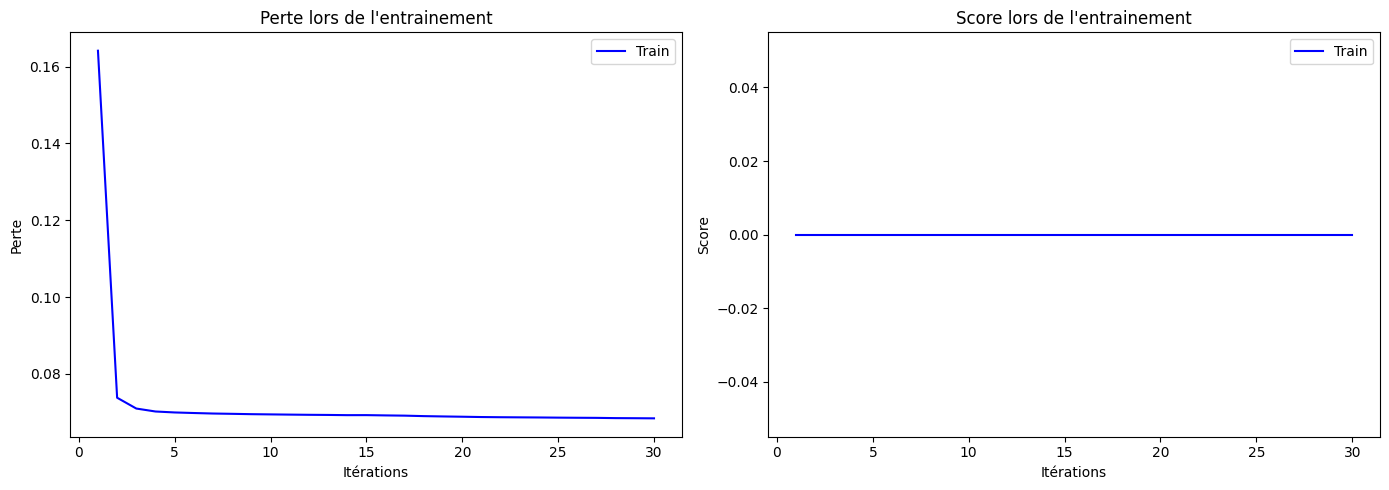

In [5]:
train(model,optimizer,nn.BCELoss(),None,dataset,None,30,16,device="mps")

In [6]:
pred = model(y_tensor.to("mps")).cpu().detach().numpy()

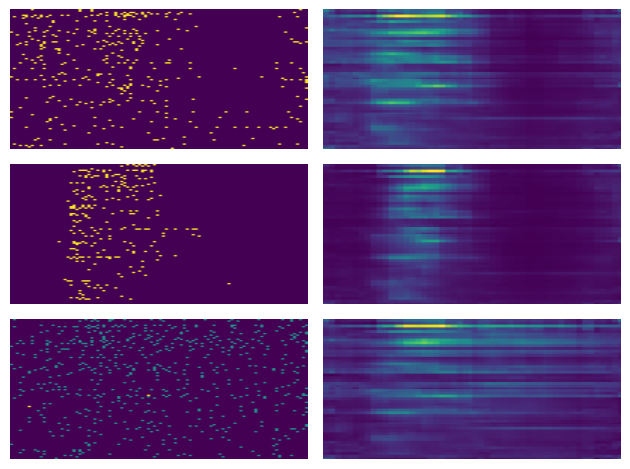

In [7]:
n_samples = 3
samples = np.random.choice(range(y_tensor.shape[0]),n_samples,replace=False)
fig, ax = plt.subplots(nrows=n_samples,ncols=2)
for i, x in enumerate(samples):
    ax[i,0].imshow(y_tensor[x][0].T,aspect="auto")
    ax[i,0].axis("off")
    ax[i,1].imshow(pred[x][0].T,aspect="auto")
    ax[i,1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
torch.save(model,"./models/response_autoencoder.pth")